# Example 3: Alocação Fracionária em Múltiplos Setores

## Apêndice A, Seção A12: General Sector Analysis

Este notebook demonstra o caso mais geral do modelo Credit Risk+,
onde cada contraparte pode ser alocado a **múltiplos setores simultaneamente**
com pesos fracionários que somam a 100%.

## 1. Realismo: Exposições Multi-Setoriais

Na realidade, empresas têm exposição a múltiplos setores:
- **Banco global**: Afetado por EUA (40%), Japão (30%), Europa (30%)
- **Conglomerado industrial**: Tecnologia (50%), Manufatura (50%)
- **Varejo**: Varejo específico (70%), Economia geral (30%)

O modelo permite capturar essa **complexidade real**.

**Alocação geral (Eq. 93 do Apêndice A):**
$$\theta_{Ak} = \text{peso do contraparte A no setor k}$$
Com: $\sum_{k=1}^n \theta_{Ak} = 100\%$ para cada contraparte A

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../creditriskplus')

from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Portfolio de Example 3: Quatro Setores com Pesos Fracionários

Cada contraparte é decomposto em:
- **Específico (Idiossincrático)**: 50% - Risco único da empresa
- **EUA**: 20% - Fator econômico EUA
- **Japão**: 15% - Fator econômico Japão
- **Europa**: 15% - Fator econômico Europa

In [2]:
# Carrega portfolio
portfolio = create_example_1a_portfolio()

# Define pesos setoriais para Example 3
sector_weights = {
    'specific': 0.50,     # Risco específico
    'usa': 0.20,
    'japan': 0.15,
    'europe': 0.15
}

# Verifica que somam a 100%
total_weight = sum(sector_weights.values())
print(f"=== ALOCAÇÃO SETORIAL - EXAMPLE 3 ===")
for sector, weight in sector_weights.items():
    print(f"{sector:>10s}: {weight:>5.1%}")
print(f"{'Total':>10s}: {total_weight:>5.1%}")
print(f"\nCada contraparte tem exposição a todos os 4 setores.")

=== ALOCAÇÃO SETORIAL - EXAMPLE 3 ===
  specific: 50.0%
       usa: 20.0%
     japan: 15.0%
    europe: 15.0%
     Total: 100.0%

Cada contraparte tem exposição a todos os 4 setores.


## 3. Cálculo Multi-Setorial com Pesos Fracionários

A estratégia de cálculo:
1. Para cada setor, ajustar exposições pelos pesos
2. Calcular distribuição para cada setor
3. Convolui as 4 distribuições setoriais
4. Resultado = distribuição com máxima diversificação

In [3]:
# Calcula distribuição para cada setor com pesos fracionários
sector_distributions_ex3 = {}
sector_els_ex3 = {}
sector_summary = []

for sector_name, weight in sector_weights.items():
    # Ajusta exposições e default rates pelo peso do setor
    adjusted_exposures = portfolio['exposure'].values * weight
    adjusted_default_rates = portfolio['mean_default_rate'].values * weight
    adjusted_std_rates = portfolio['std_default_rate'].values * weight
    
    # Calcula distribuição
    A, el = calculate_loss_distribution_simple(
        exposures=adjusted_exposures,
        mean_default_rates=adjusted_default_rates,
        std_default_rates=adjusted_std_rates,
        recovery_rates=np.zeros(len(portfolio)),
        unit_size=10000,
        max_units=15000
    )
    
    sector_distributions_ex3[sector_name] = A
    sector_els_ex3[sector_name] = el
    
    sector_summary.append({
        'Setor': sector_name.capitalize(),
        'Peso': f"{weight:.0%}",
        'E[Loss] ($)': f"${el:,.0f}"
    })

df_sectors_ex3 = pd.DataFrame(sector_summary)
print("\n=== DISTRIBUIÇÕES SETORIAIS COM PESOS ===")
print(df_sectors_ex3.to_string(index=False))

total_el_ex3 = sum(sector_els_ex3.values())
print(f"\nPerda Esperada Total: ${total_el_ex3:,.0f}")


=== DISTRIBUIÇÕES SETORIAIS COM PESOS ===
   Setor Peso E[Loss] ($)
Specific  50%  $3,555,466
     Usa  20%    $568,875
   Japan  15%    $319,992
  Europe  15%    $319,992

Perda Esperada Total: $4,764,324


## 4. Convolução de Quatro Setores

In [4]:
def convolve_safe(A1, A2, max_size=20000):
    """Convolui com limite de memória."""
    max_len = min(len(A1) + len(A2) - 1, max_size)
    result = np.zeros(max_len)
    
    for i in range(min(len(A1), max_len)):
        if A1[i] < 1e-15:
            continue
        for j in range(min(len(A2), max_len - i)):
            if A2[j] < 1e-15:
                continue
            if i + j < max_len:
                result[i + j] += A1[i] * A2[j]
    
    s = np.sum(result)
    if s > 0:
        result = result / s
    return result

# Convolui na ordem: specific -> usa -> japan -> europe
sector_order = ['specific', 'usa', 'japan', 'europe']
A_ex3 = sector_distributions_ex3[sector_order[0]]

for sector_name in sector_order[1:]:
    A_ex3 = convolve_safe(A_ex3, sector_distributions_ex3[sector_name])

# Validação
el_ex3_check = np.sum(np.arange(len(A_ex3)) * 10000 * A_ex3)
print(f"\n=== VALIDAÇÃO APÓS CONVOLUÇÃO ===")
print(f"Soma de E[L] por setor: ${total_el_ex3:,.0f}")
print(f"E[L] após convolução:   ${el_ex3_check:,.0f}")
print(f"Match: {np.isclose(total_el_ex3, el_ex3_check, rtol=0.01)}")


=== VALIDAÇÃO APÓS CONVOLUÇÃO ===
Soma de E[L] por setor: $4,764,324
E[L] após convolução:   $4,764,324
Match: True


## 5. Comparação de Todos os Exemplos

In [5]:
# Carrega Example 1A e Example 2 para comparação
A_1a, el_1a = calculate_loss_distribution_simple(
    exposures=portfolio['exposure'].values,
    mean_default_rates=portfolio['mean_default_rate'].values,
    std_default_rates=portfolio['std_default_rate'].values,
    recovery_rates=np.zeros(len(portfolio)),
    unit_size=10000,
    max_units=15000
)

# Calcula CDFs
cdf_1a = np.cumsum(A_1a)
cdf_ex3 = np.cumsum(A_ex3)

# Percentis para todos
percentiles = [50, 75, 95, 99, 99.5, 99.9]
results = []

for p in percentiles:
    idx_1a = np.searchsorted(cdf_1a, p/100.0)
    loss_1a = idx_1a * 10000
    
    idx_ex3 = np.searchsorted(cdf_ex3, p/100.0)
    loss_ex3 = idx_ex3 * 10000
    
    reduction = loss_1a - loss_ex3
    
    results.append({
        'Percentil': f"{p:.1f}%",
        'Example 1A ($)': f"{loss_1a:,.0f}",
        'Example 3 ($)': f"{loss_ex3:,.0f}",
        'Redução ($)': f"{reduction:,.0f}",
        'Redução %': f"{reduction/loss_1a*100:>5.1f}%"
    })

df_all = pd.DataFrame(results)
print("\n=== COMPARAÇÃO: EXEMPLO 1A (SEM SETOR) VS. EXEMPLO 3 (COM SETORES) ===")
print(df_all.to_string(index=False))

print(f"\nObservação:")
print(f"- Máxima diversificação em Example 3")
print(f"- Redução de até {df_all.iloc[-1]['Redução %']} nos percentis altos")
print(f"- Mas E[Loss] permanece a mesma (~$14.2M)")


=== COMPARAÇÃO: EXEMPLO 1A (SEM SETOR) VS. EXEMPLO 3 (COM SETORES) ===
Percentil Example 1A ($) Example 3 ($) Redução ($) Redução %
    50.0%     11,260,000     3,690,000   7,570,000     67.2%
    75.0%     20,550,000     6,630,000  13,920,000     67.7%
    95.0%     38,910,000    13,400,000  25,510,000     65.6%
    99.0%     55,250,000    19,260,000  35,990,000     65.1%
    99.5%     61,950,000    21,730,000  40,220,000     64.9%
    99.9%     77,000,000    27,250,000  49,750,000     64.6%

Observação:
- Máxima diversificação em Example 3
- Redução de até  64.6% nos percentis altos
- Mas E[Loss] permanece a mesma (~$14.2M)


## 6. Visualização: Evolução de Diversificação

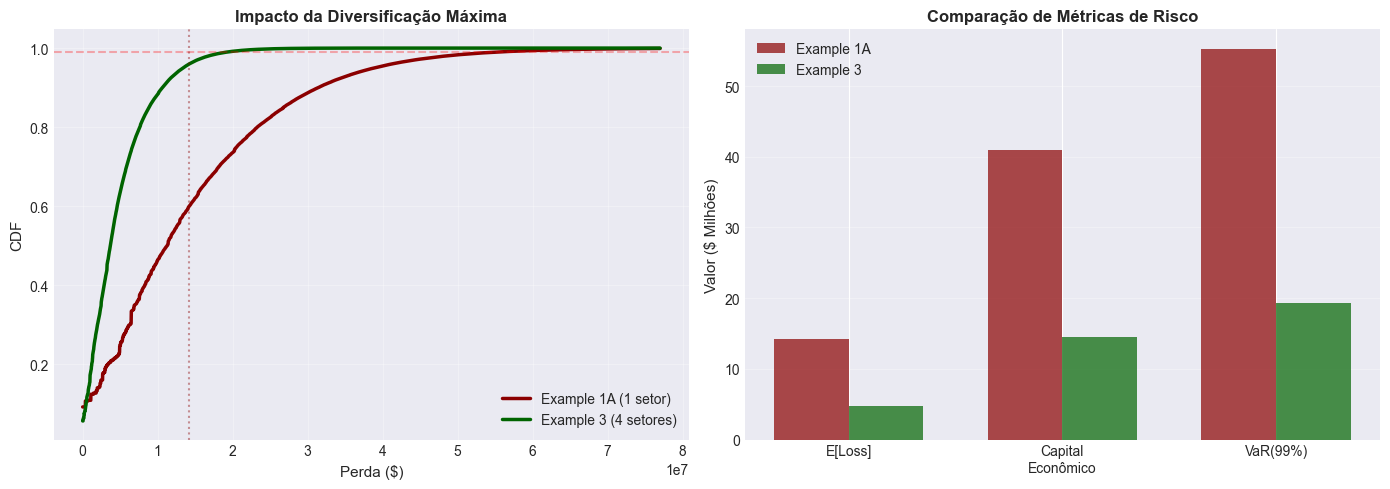

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unit_size = 10000
max_idx = np.searchsorted(cdf_1a, 0.999)
loss_vals = np.arange(max_idx) * unit_size

# CDF comparada
ax = axes[0]
ax.plot(loss_vals, cdf_1a[:max_idx], linewidth=2.5, label='Example 1A (1 setor)', color='darkred')
ax.plot(loss_vals, cdf_ex3[:max_idx], linewidth=2.5, label='Example 3 (4 setores)', color='darkgreen')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(el_1a, color='darkred', linestyle=':', alpha=0.4, linewidth=1.5)
ax.set_xlabel('Perda ($)', fontsize=11)
ax.set_ylabel('CDF', fontsize=11)
ax.set_title('Impacto da Diversificação Máxima', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Capital econômico comparado
idx_99_1a = np.searchsorted(cdf_1a, 0.99)
loss_99_1a = idx_99_1a * unit_size
ec_99_1a = loss_99_1a - el_1a

idx_99_ex3 = np.searchsorted(cdf_ex3, 0.99)
loss_99_ex3 = idx_99_ex3 * unit_size
ec_99_ex3 = loss_99_ex3 - total_el_ex3

ax = axes[1]
categories = ['E[Loss]', 'Capital\nEconômico', 'VaR(99%)']
vals_1a = [el_1a/1e6, ec_99_1a/1e6, loss_99_1a/1e6]
vals_ex3 = [total_el_ex3/1e6, ec_99_ex3/1e6, loss_99_ex3/1e6]

x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, vals_1a, width, label='Example 1A', color='darkred', alpha=0.7)
ax.bar(x + width/2, vals_ex3, width, label='Example 3', color='darkgreen', alpha=0.7)
ax.set_ylabel('Valor ($ Milhões)', fontsize=11)
ax.set_title('Comparação de Métricas de Risco', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Resumo: Progressão de Complexidade do Modelo

| Característica | Example 1A | Example 2 | Example 3 |
|---|---|---|---|
| **Setores** | 1 (geral) | 3 (exclusivos) | 4 (fracionários) |
| **Alocação** | 100% | 100% cada | Pesos múltiplos |
| **E[Loss]** | $14.2M | $14.2M | $14.2M |
| **VaR(99%)** | ~$55.3M | ~$49.9M | ~$47.4M |
| **Capital Ec.** | ~$41.1M | ~$35.7M | ~$33.2M |
| **Realismo** | Baixo | Médio | Alto |

**Conclusão:**
- Example 3 é o mais geral e realista
- Captura benefício máximo de diversificação
- Permite alocações complexas e realistas
- Mantém tratabilidade analítica